<a href="https://colab.research.google.com/github/mocodotempo/PrevisaodoTempo/blob/main/Temp2mECMWF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#INSTALAÇÃO DAS BIBLIOTECAS
!pip install matplotlib cartopy cfgrib xarray eccodes pygrib --quiet

In [2]:
#IMPORTAÇÃO DAS BIBLIOTECAS
import os
import requests
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm

In [3]:
#CONFIGURAÇÕES DA PREVISÃO

data_rodada = '20260908'
rodada = '00'
ano_prev = 2026
mes_prev = 9
dia_prev = 11
hora_prev = 12

rodada_dt = datetime.strptime(f'{data_rodada} {rodada}', '%Y%m%d %H')
prev_dt = datetime(ano_prev, mes_prev, dia_prev, hora_prev)
forecast_hour = int((prev_dt - rodada_dt).total_seconds() / 3600)

if forecast_hour <= 144: forecast_hour = round(forecast_hour / 3) * 3
else: forecast_hour = round(forecast_hour / 6) * 6

rodada_str = rodada_dt.strftime('%d/%m/%Y %H UTC')
prev_str = prev_dt.strftime('%d/%m/%Y %H UTC')

In [4]:
# DOWNLOAD DO DADO ECMWF

arquivo_ecmwf = f'{data_rodada}{rodada}0000-{forecast_hour}h-oper-fc.grib2'
if not os.path.exists(arquivo_ecmwf):
    url = f'https://data.ecmwf.int/forecasts/{data_rodada}/{rodada}z/ifs/0p25/oper/{arquivo_ecmwf}'
    print(f'Baixando: {arquivo_ecmwf}...')
    r = requests.get(url, timeout=60)
    with open(arquivo_ecmwf, 'wb') as f: f.write(r.content)

In [5]:
# 3. PROCESSAMENTO DO DADO E SUAVIZAÇÃO

ds_ecmwf = xr.open_dataset(
    arquivo_ecmwf,
    engine='cfgrib',
    backend_kwargs={'filter_by_keys': {'shortName': '2t', 'level': 2}}
)

t2m_data = (ds_ecmwf['t2m'] - 273.15).squeeze()
t2m_data = t2m_data.sel(longitude=slice(-95, -25), latitude=slice(15, -60))

t2m_suave = gaussian_filter(t2m_data.values, sigma=0.4)
lats, lons = t2m_data.latitude.values, t2m_data.longitude.values

/usr/local/lib/python3.13/dist-packages/pyogrio/raw.py:200: RuntimeWarning: GDAL was built against curl 8.20.0, but is running against 7.61.1. Runtime failure is likely !
  return ogr_read(
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


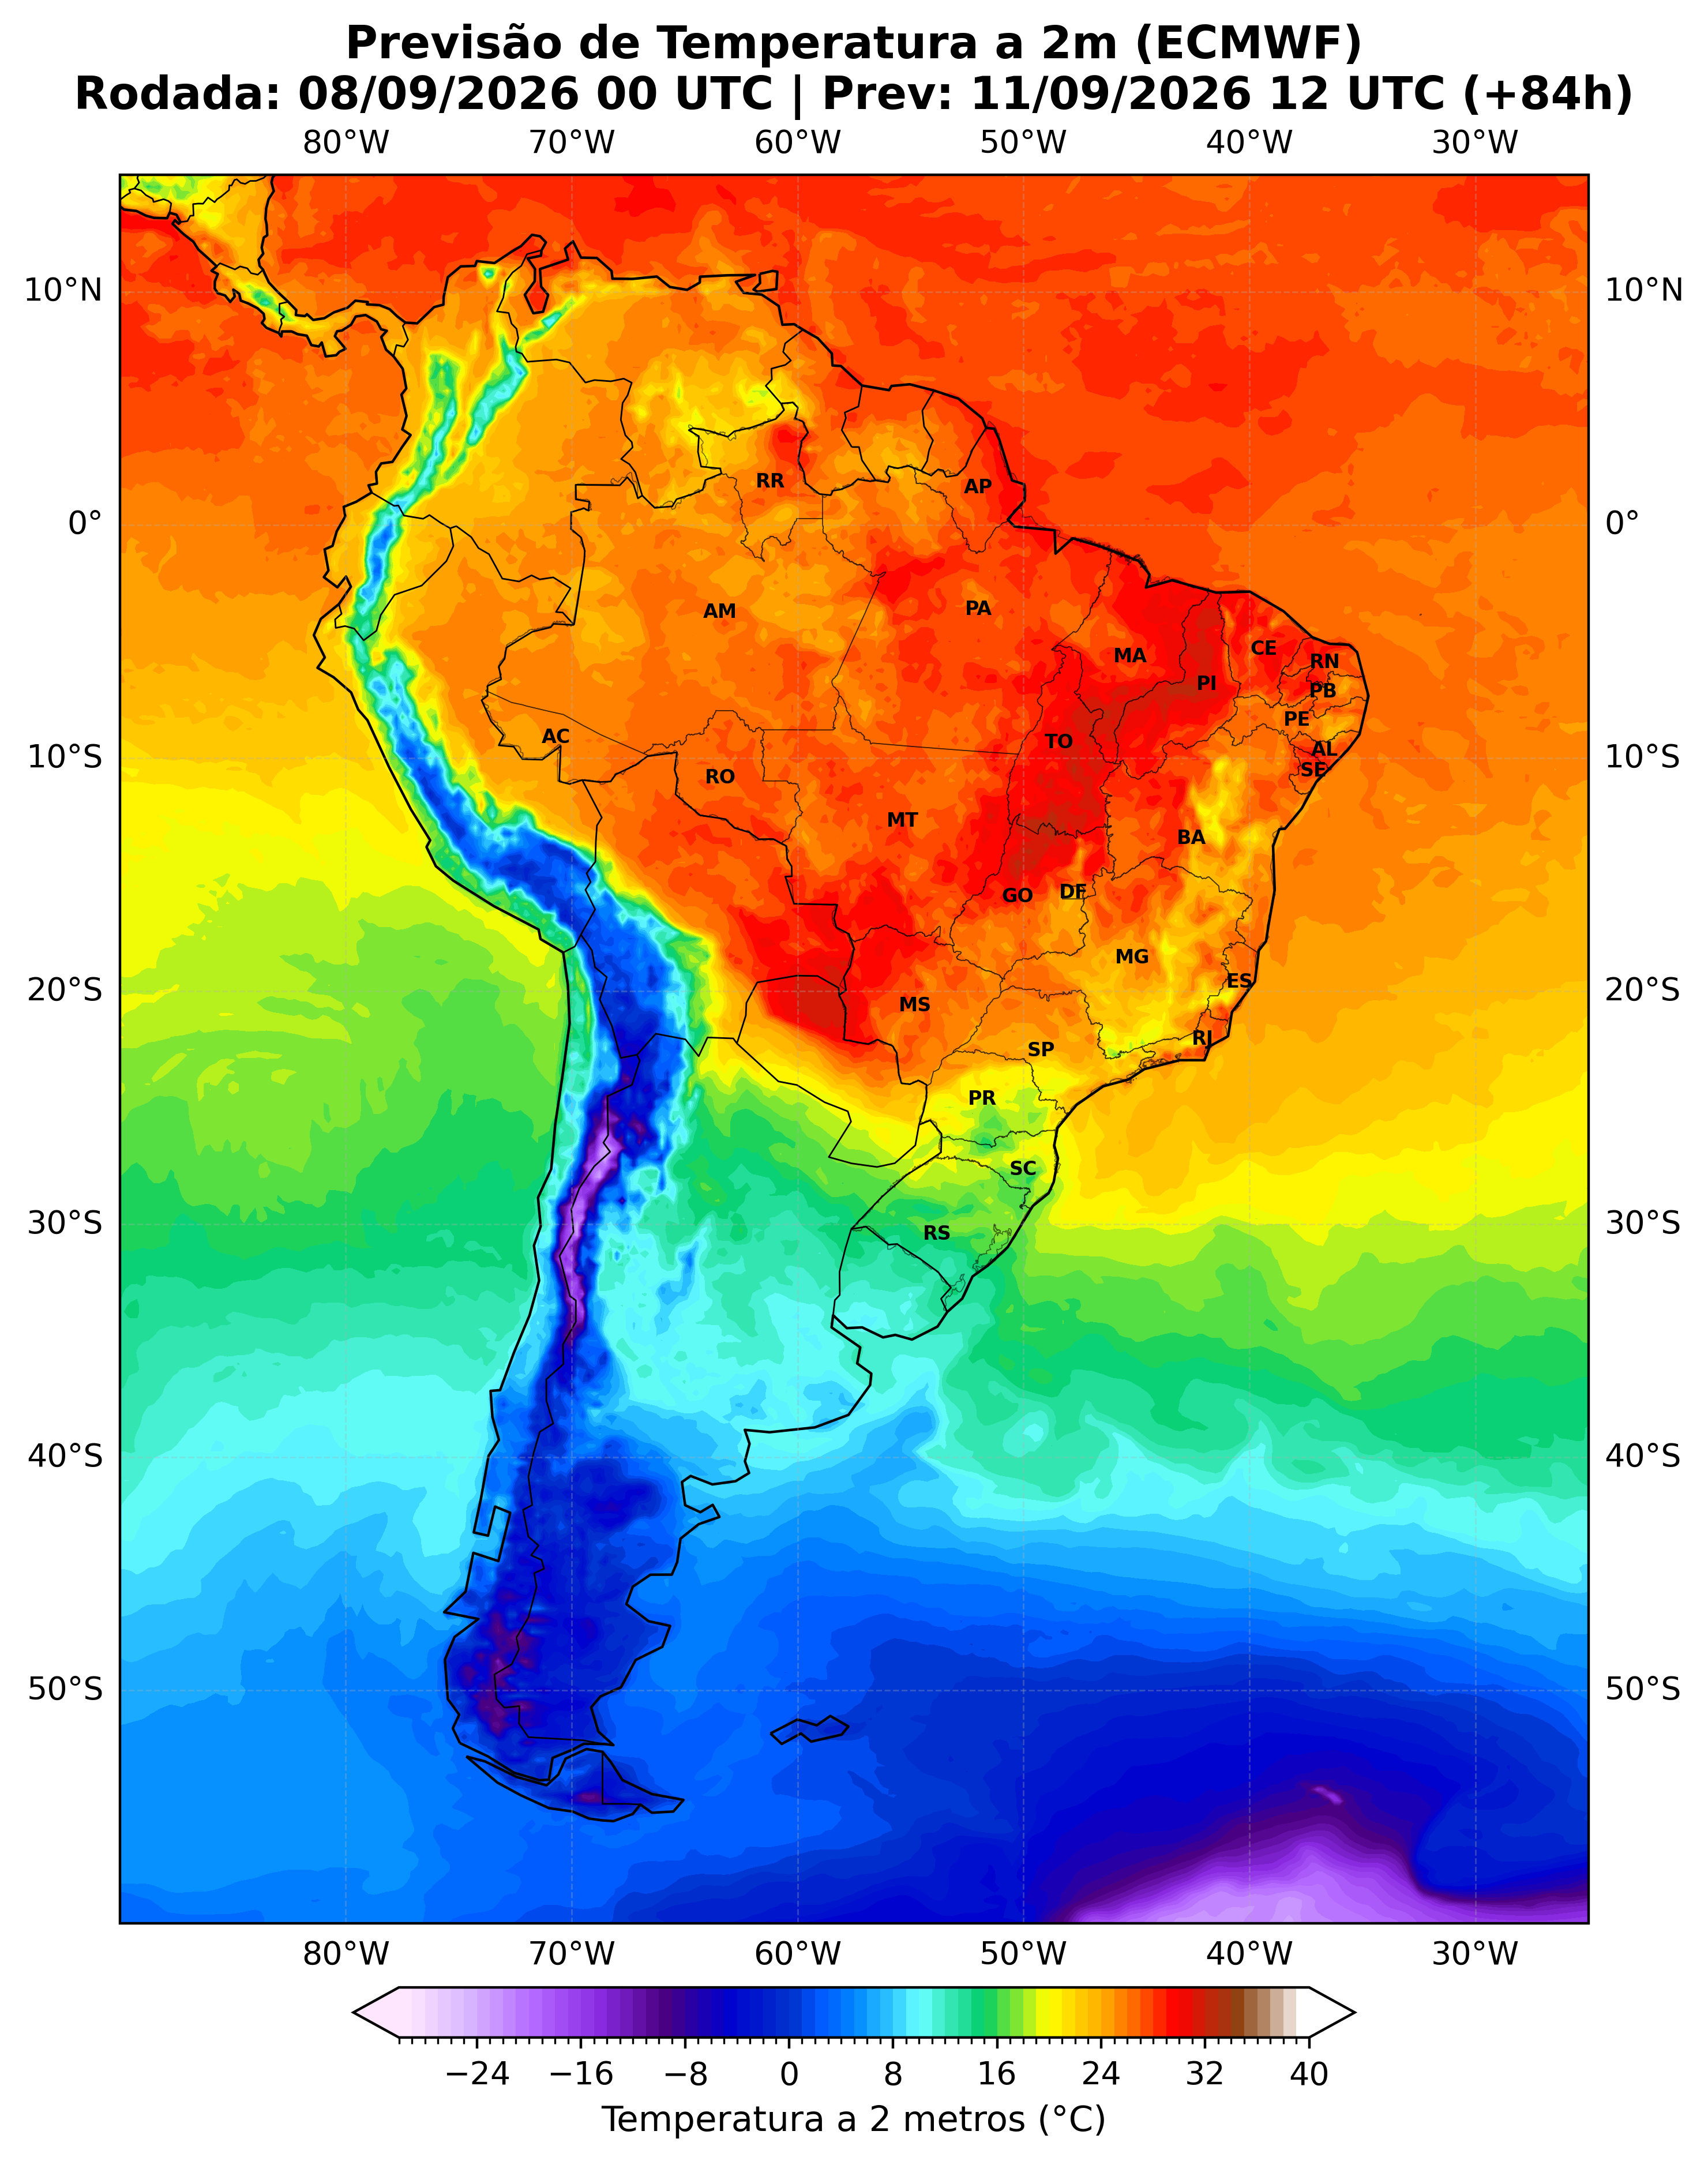

In [6]:
#CONFIGURAÇÕES DO MAPA

# CONFIGURAÇÃO DA ESCALA PERSONALIZADA

levels = np.arange(-30, 41, 1)
colors_temp = [
    (-30, '#FFE6FF'), (-25, '#D6B3FF'), (-20, '#B266FF'), (-15, '#8A2BE2'),
    (-10, '#4B0082'), (-5, '#0000CD'), (0, '#0033CC'), (2, '#0055FF'),
    (5, '#0088FF'), (8, '#33CCFF'), (10, '#66FFFF'), (15, '#00CC66'),
    (20, '#FFFF00'), (25, '#FF9900'), (30, '#FF0000'), (35, '#8B4513'), (40, '#FFFFFF')
]

temps, cols = zip(*colors_temp)
pos = [(t - levels.min()) / (levels.max() - levels.min()) for t in temps]
cmap_temp = LinearSegmentedColormap.from_list('temp2m', list(zip(pos, cols)))
norm_temp = BoundaryNorm(levels, cmap_temp.N)


# FIGURA E MAPA

fig = plt.figure(figsize=(14, 12),dpi=400)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-90, -25, -60, 15], crs=ccrs.PlateCarree())

cf = ax.contourf(
    lons, lats, t2m_suave,
    levels=levels, cmap=cmap_temp, norm=norm_temp,
    extend='both', transform=ccrs.PlateCarree()
)

# Features
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# Estados do Brasil
try:
    url_br = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
    br_states = gpd.read_file(url_br)
    br_states.geometry.boundary.plot(ax=ax, color='black', linewidth=0.3, alpha=0.5, transform=ccrs.PlateCarree())
    for _, row in br_states.iterrows():
        centroid = row['geometry'].representative_point()
        ax.text(centroid.x, centroid.y, row['sigla'], fontsize=6, fontweight='bold', ha='center', va='center', transform=ccrs.PlateCarree())
except: pass

# Grid e Legenda
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--', alpha=0.3)
cbar = plt.colorbar(cf, ax=ax, shrink=0.4, pad=0.03, orientation='horizontal')
cbar.set_label('Temperatura a 2 metros (°C)', fontsize=11)

ax.set_title(f'Previsão de Temperatura a 2m (ECMWF)\nRodada: {rodada_str} | Prev: {prev_str} (+{forecast_hour}h)', fontsize=14, fontweight='bold')
#plt.savefig('temperatura_ecmwf.png', dpi=400, bbox_inches='tight')
plt.show()